In [ ]:
# Data Augentation ----->>>>

In [ ]:

%%capture
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


In [ ]:
%%capture
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

In [ ]:
num_classes = metadata.features['label'].num_classes
print(num_classes)

2


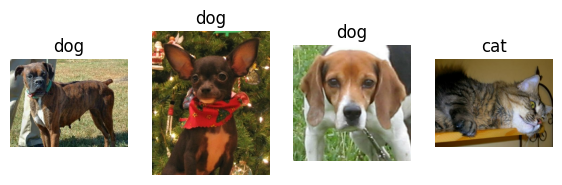

In [ ]:
try:
    get_label_name = metadata.features['label'].int2str
    train_iter = iter(train_ds)
    fig = plt.figure(figsize=(7, 8))
    for x in range(4):
        image, label = next(train_iter)
        fig.add_subplot(1, 4, x + 1)
        plt.imshow(image)
        plt.axis('off')
        plt.title(get_label_name(label))
except StopIteration:
    print("Dataset iterator is empty!")


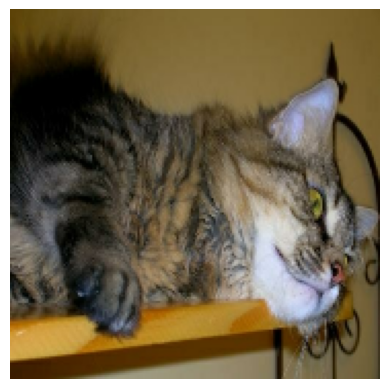

In [ ]:
IMG_SIZE = 180

resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMG_SIZE, IMG_SIZE),
  layers.Rescaling(1./255)
])

result = resize_and_rescale(image)
plt.axis('off')
plt.imshow(result);

In [ ]:
# Rotate And Flip

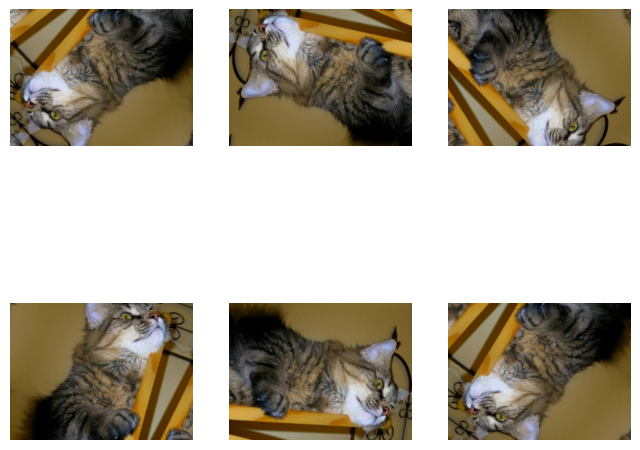

In [ ]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.4),
])


plt.figure(figsize=(8, 7))
for i in range(6):
  augmented_image = data_augmentation(image)
  ax = plt.subplot(2, 3, i + 1)
  plt.imshow(augmented_image.numpy()/255)
  plt.axis("off")

In [ ]:
# First Method for applying Data Augementation

In [ ]:
# Preprocessing function
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [ ]:
# Parameters
# IMG_SIZE = 180
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# Apply preprocessing
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)


In [ ]:
# Optimize dataset
train_ds = train_ds.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
# Data augmentation (NO Input layer here!)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
# Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')  # Binary classification
])

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,033 (125.13 KB)

 Trainable params: 32,033 (125.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train
EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 703s 1s/step - accuracy: 0.5724 - loss: 0.6746 - val_accuracy: 0.5649 - val_loss: 0.6931
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 687s 1s/step - accuracy: 0.6274 - loss: 0.6417 - val_accuracy: 0.6518 - val_loss: 0.6249
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 639s 1s/step - accuracy: 0.6639 - loss: 0.6130 - val_accuracy: 0.6819 - val_loss: 0.5906
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 670s 1s/step - accuracy: 0.6803 - loss: 0.5981 - val_accuracy: 0.7012 - val_loss: 0.5830
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 638s 1s/step - accuracy: 0.6960 - loss: 0.5827 - val_accuracy: 0.6866 - val_loss: 0.5867
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 667s 1s/step - accuracy: 0.7047 - loss: 0.5721 - val_accuracy: 0.7077 - val_loss: 0.5622
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 654s 1s/step - accuracy: 0.7124 - loss: 0.5660 - val_accuracy: 0.6913 - val_loss: 0.5901
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 685s 1s/step - accuracy: 0.7185 - loss: 0.5557 - val_accu

In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, (180, 180))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [ ]:
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

73/73 ━━━━━━━━━━━━━━━━━━━━ 22s 304ms/step - accuracy: 0.7438 - loss: 0.5263
Test Accuracy: 0.7437661290168762


In [ ]:
# Data Augemtnation -----> small datasets ---> large datasets ---> model performance best ,
# overfitting reduce

# Data Augmentation ---> variable ---> paramerters (zoom in ,zoom out , left , right , horizontal)

# DataSet ---> Resize and Rescale

# Model Sequential(
#     Input_data_dimension,
#     Data Augemtnation,
#     cov,
#     pooling,
#     flatten layer,
#     dense layer
# )

# Model.compile(optimizer , loss , metrics)
# Model training
# Model Prediction and Evaluation